### **LAB 9**

**Part A: Support Vector Machine (SVM)**

**1. Load the dataset and perform the necessary preprocessing.**

In [10]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [13]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFirst 5 rows of features:")
display(X.head())

print("\nFirst 5 rows of target:")
display(y.head())

print("\nMissing values:")
print(X.isnull().sum().sum())

print("\nTarget values:")
print(y.value_counts())

Features Shape: (569, 30)
Target Shape: (569, 1)

First 5 rows of features:


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



First 5 rows of target:


,Diagnosis
0,M
1,M
2,M
3,M
4,M



Missing values:
0

Target values:
Diagnosis
B            357
M            212
Name: count, dtype: int64


In [14]:
y = y["Diagnosis"].map({
    "B": 0,
    "M": 1
})

print(y.value_counts())

Diagnosis
0    357
1    212
Name: count, dtype: int64


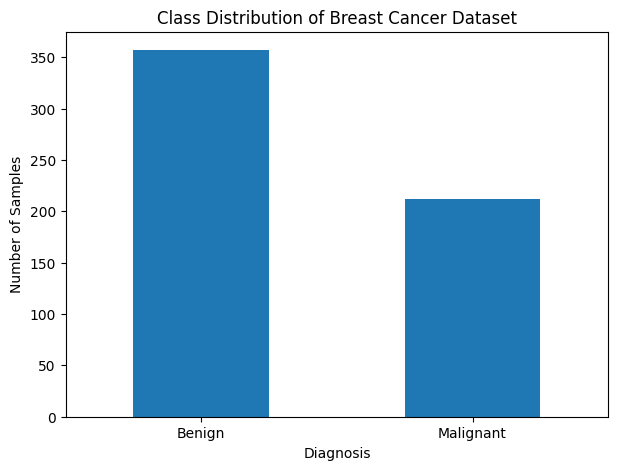

In [32]:
plt.figure(figsize=(7, 5))

y.value_counts().sort_index().plot(kind="bar")

plt.xticks(
    [0, 1],
    ["Benign", "Malignant"],
    rotation=0
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Breast Cancer Dataset")

plt.show()

In [15]:
if "ID" in X.columns:
    X = X.drop(columns=["ID"])

print("Features after removing ID:", X.shape)

Features after removing ID: (569, 30)


The dataframe may contain ID column which should not be used as a predictive feature. So I am removinh unnecessary ID column if present 

In [16]:
print("Missing values in each column:")
print(X.isnull().sum())

print("\nTotal missing values:", X.isnull().sum().sum())

Missing values in each column:
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64

Total missing values: 0


Since there is no missing values, no missing value treatment is required

**2. Split the dataset into training and testing sets (80:20).**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standardization completed.")

Standardization completed.


Standardization is important because the SVM features have different scales and standardization help to bring the features within a particular scale

**3. Train an SVM classifier using a Linear Kernel and explore hyper parameter tuning.**

In [33]:
from sklearn.svm import SVC
svm_model = SVC(
    kernel="linear",
    C=1.0
)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)

**4. Evaluate the model using:<br>
Accuracy<br>
Precision<br>
Recall<br>
F1 Score<br>
Confusion Matrix**

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("SVM Performance")
print("----------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

SVM Performance
----------------------
Accuracy  : 0.9649
Precision : 1.0000
Recall    : 0.9048
F1 Score  : 0.9500


Confusion Matrix:
[[72  0]
 [ 4 38]]


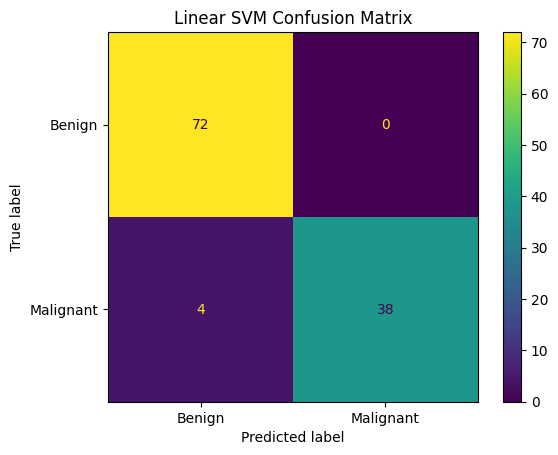

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)
disp.plot()
plt.title("Linear SVM Confusion Matrix")
plt.show()

**5. Summarize your observations.**

The Linear SVM achieved 96.49% accuracy with an F1 score of 95% which shows the overall classification performance is good. The confusion matrix shows that 72 benign and 38 malignant cases were correctly classified while only 4 malignant cases were misclassified as benign. This indicate that the model performed well but could still improve in detecting some malignant cases.


**Part B: Principal Component Analysis (PCA)**

**1. Load the dataset and perform feature standardization**

In [36]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine = fetch_ucirepo(id=109) 
  
# data (as pandas dataframes) 
X = wine.data.features 
y = wine.data.targets 
  
# metadata 
print(wine.metadata) 
  
# variable information 
print(wine.variables) 


{'uci_id': 109, 'name': 'Wine', 'repository_url': 'https://archive.ics.uci.edu/dataset/109/wine', 'data_url': 'https://archive.ics.uci.edu/static/public/109/data.csv', 'abstract': 'Using chemical analysis to determine the origin of wines', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 178, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1992, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C5PC7J', 'creators': ['Stefan Aeberhard', 'M. Forina'], 'intro_paper': {'ID': 246, 'type': 'NATIVE', 'title': 'Comparative analysis of statistical pattern recognition methods in high dimensional settings', 'authors': 'S. Aeberhard, D. Coomans, O. Vel', 'venue': 'Pattern Recognition', 'year': 1994, 'journal': None, 'DOI': '10.1016/0031-3203(94)90145-7', 'URL': 'https:

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Original shape:", X.shape)
print("Standardized shape:", X_scaled.shape)

Original shape: (178, 13)
Standardized shape: (178, 13)


**2. Apply PCA to reduce the dataset from 13 features to 2 principal components.**

In [38]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Original dataset shape:", X.shape)
print("Transformed dataset shape:", X_pca.shape)

Original dataset shape: (178, 13)
Transformed dataset shape: (178, 2)


**3. Display the explained variance ratio of each principal component.**

In [39]:
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
for i, value in enumerate(explained_variance, start=1):
    print(f"PC{i}: {value:.4f} ({value * 100:.2f}%)")

Explained Variance Ratio:
PC1: 0.3620 (36.20%)
PC2: 0.1921 (19.21%)


**4. Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.**

In [41]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_variance_full = pca_full.explained_variance_ratio_
cumulative_variance = explained_variance_full.cumsum()
print("Cumulative Explained Variance:")
for i, value in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {value:.4f} ({value * 100:.2f}%)")

Cumulative Explained Variance:
PC1: 0.3620 (36.20%)
PC2: 0.5541 (55.41%)
PC3: 0.6653 (66.53%)
PC4: 0.7360 (73.60%)
PC5: 0.8016 (80.16%)
PC6: 0.8510 (85.10%)
PC7: 0.8934 (89.34%)
PC8: 0.9202 (92.02%)
PC9: 0.9424 (94.24%)
PC10: 0.9617 (96.17%)
PC11: 0.9791 (97.91%)
PC12: 0.9920 (99.20%)
PC13: 1.0000 (100.00%)


In [42]:
n_components_95 = (
    (cumulative_variance >= 0.95).argmax() + 1
)

print("\nMinimum number of components required for 95% variance:",
      n_components_95)

print("Variance retained:",
      f"{cumulative_variance[n_components_95 - 1] * 100:.2f}%")


Minimum number of components required for 95% variance: 10
Variance retained: 96.17%


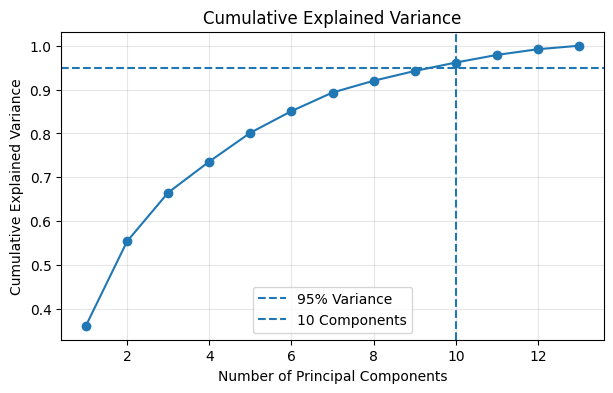

In [43]:
plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.axvline(
    x=n_components_95,
    linestyle="--",
    label=f"{n_components_95} Components"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**5. Visualize the transformed dataset using a two dimensional scatter plot.**

In [44]:
print(y.head())
print(y.columns)

   class
0      1
1      1
2      1
3      1
4      1
Index(['class'], dtype='object')


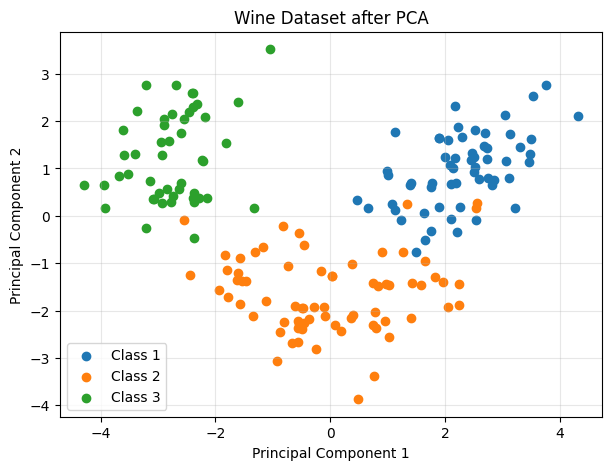

In [45]:
plt.figure(figsize=(7, 5))

classes = y.iloc[:, 0].unique()

for class_value in sorted(classes):

    mask = y.iloc[:, 0] == class_value

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Class {class_value}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset after PCA")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

**6. Compare the original and transformed datasets in terms of:<br>
Number of features<br>
Information retained<br>
Computational efficiency**


In [46]:
import pandas as pd

comparison = pd.DataFrame({
    "Property": [
        "Number of Samples",
        "Original Number of Features",
        "Transformed Number of Features",
        "Feature Reduction",
        "Variance Retained by PC1 + PC2",
        "Components Required for 95% Variance"
    ],
    
    "Value": [
        X.shape[0],
        X.shape[1],
        X_pca.shape[1],
        f"{X.shape[1]} → {X_pca.shape[1]}",
        f"{explained_variance.sum() * 100:.2f}%",
        n_components_95
    ]
})

display(comparison)

,Property,Value
0,Number of Samples,178
1,Original Number of Features,13
2,Transformed Number of Features,2
3,Feature Reduction,13 → 2
4,Variance Retained by PC1 + PC2,55.41%
5,Components Required for 95% Variance,10


**7. Interpret the significance of the first two principal components.**

In [47]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

display(loadings)

,PC1,PC2
Alcohol,0.144329,0.483652
Malicacid,-0.245188,0.224931
Ash,-0.002051,0.316069
Alcalinity_of_ash,-0.239320,-0.010591
Magnesium,0.141992,0.299634
Total_phenols,0.394661,0.065040
Flavanoids,0.422934,-0.003360
Nonflavanoid_phenols,-0.298533,0.028779
Proanthocyanins,0.313429,0.039302
Color_intensity,-0.088617,0.529996


In [48]:
print("Top features contributing to PC1:")

display(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .head()
)

print("\nTop features contributing to PC2:")

display(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .head()
)

Top features contributing to PC1:


Flavanoids                      0.422934
Total_phenols                   0.394661
0D280_0D315_of_diluted_wines    0.376167
Proanthocyanins                 0.313429
Nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64


Top features contributing to PC2:


Color_intensity    0.529996
Alcohol            0.483652
Proline            0.364903
Ash                0.316069
Magnesium          0.299634
Name: PC2, dtype: float64

Interpretation:

PC1: It is mainly influenced by Flavanoids and Total_phenols representing variation related to the phenolic properties of wine. 

PC2: Mainly influenced by Color_intensity and Alcohol, representing variation related to the chemical composition of the wine. 

**8. Discuss the advantages, limitations, and applications of PCA in machine learning.**

Advantages:

* Reduces the no. of features & makes the dataset easier to process<br>
* Reduces computational time & helps visualize high-dimensional data<br>
* Removes some redundancy from correlated features<br>

Limitations:

* Some information may be lost during reduction<br>
* Principal components can be difficult to interpret<br>
* PCA is sensitive to the scale of the features and mainly works with linear relationships<br>

Applications:

* Data visualization and exploratory data analysis.<br>
* Feature reduction before machine learning.<br>
* Image processing and pattern recognition.<br>
* Noise reduction and data compression.
